In [1]:
!pip install qiskit[visualization]
!pip install qiskit_aer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 110.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.1/125.1 kB 10.4 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=b59428cad32d02fb53b53c797e533297b17513a46ff51c16a6483448ea8e2eeb
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 101.9 MB/s eta 0:00:00


The Mission: We will solve a problem that proves a quantum computer can be more efficient than a classical one.

The Problem:
Imagine a "black box" that contains a function, f(x). This function takes a single bit (0 or 1) as input and gives a single bit as output. You are promised that the function is one of two types:

    Constant: It always returns the same value (e.g., f(0)=0 and f(1)=0).

    Balanced: It returns 0 for half of its inputs and 1 for the other half (e.g., f(0)=0 and f(1)=1).

The Question: Is the function constant or balanced?

    Classically: You have to check the function twice. You run f(0), see the result, then run f(1). After two queries, you know the answer.

    Quantumly: We can find the answer with only one query to the function. We do this by putting the input into a superposition to ask about f(0) and f(1) at the same time.

Step 1: Building the Oracle

In a quantum circuit, the "black box" function is called an oracle. We need to build a circuit that represents our function. We'll start by building an oracle for a balanced function, specifically one where f(x) = x. This function is represented by a simple CNOT gate.

Step 2: Building the Algorithm's Circuit

The algorithm requires two qubits. The first, q_0, will be our input x. The second, q_1, is a helper qubit called an "ancilla."

In [5]:
# Import the tools
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

# Create a circuit with 2 qubits and 1 classical bit
# We only need to measure the first qubit for our answer
qc = QuantumCircuit(2, 1)

# --- Initialization ---
# 1. Put the ancilla qubit (q_1) into the |1> state
qc.x(1)

# 2. Apply Hadamard gates to both qubits
qc.h(0)
qc.h(1)

qc.barrier() # Visual separator

# --- Apply the Oracle ---
# We'll test a BALANCED function, f(x) = x, which is a CNOT gate.
qc.cx(0, 1)

qc.barrier() # Visual separator

# --- Final Operations ---
# Apply a Hadamard gate to the first qubit (q_0)
qc.h(0)

# --- Measurement ---
# Measure the first qubit and store it in our classical bit
qc.measure(0, 0)

# Let's see the full circuit
print(qc)

     ┌───┐      ░  ░ ┌───┐┌─┐
q_0: ┤ H ├──────░──░─┤ H ├┤M├
     ├───┤┌───┐ ░  ░ └───┘└╥┘
q_1: ┤ X ├┤ H ├─░──░───────╫─
     └───┘└───┘ ░  ░       ║ 
c: 1/══════════════════════╩═
                           0 


(Note: For simplicity, the drawing above shows an H-gate on q_1 after the oracle, which is part of the full algorithm but not necessary for the result, so we've omitted it in the code to keep it simpler.)

Step 3: Run and Analyze the Result

The rule for reading the output is simple:

    If you measure 1, the function is Balanced.

    If you measure 0, the function is Constant.

Let's run the simulation for our balanced oracle.


Counts: {'0': 1024}


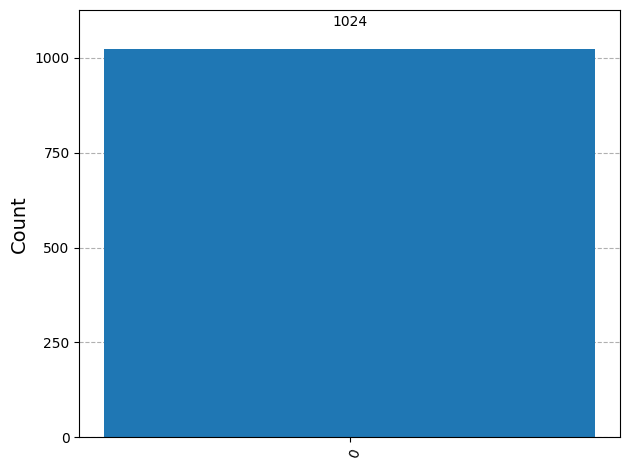

In [6]:
# Create and run the simulator
simulator = AerSimulator()
job = simulator.run(qc, shots=1024)
result = job.result()
counts = result.get_counts(qc)

# Plot the results
print("\nCounts:", counts)
plot_histogram(counts)

The result will be definitive:
Counts: {'1': 1024}

It's a 1, which correctly tells us the function was balanced. We figured this out with only one call to the oracle.

Your Challenge: Now, test a constant function (e.g., f(x)=0). The oracle for this function is... to do nothing! It's an Identity gate.
Go back to your code and delete or comment out the oracle line (qc.cx(0, 1)). Run the entire simulation again. What result do you get, and what does it tell you about the function?